# Essential Librires

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# Loading Data..........................

In [2]:
file = pd.read_csv('Weather Records - Weather Records.csv')

data = file.copy()

print(f"Shape of the Data = {data.shape}\n\n\n")
print("***Data Information***")
data.info()
print('\n\n\n\n\n')

Shape of the Data = (10582, 13)



***Data Information***
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10582 entries, 0 to 10581
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Type               10545 non-null  object 
 1   Severity           10545 non-null  object 
 2   StartTime(UTC)     10576 non-null  object 
 3   EndTime(UTC)       10576 non-null  object 
 4   Precipitation(in)  10528 non-null  float64
 5   TimeZone           10576 non-null  object 
 6   AirportCode        10576 non-null  object 
 7   LocationLat        10570 non-null  float64
 8   LocationLng        10570 non-null  float64
 9   City               10437 non-null  object 
 10  County             10437 non-null  object 
 11  State              10416 non-null  object 
 12  ZipCode            10563 non-null  float64
dtypes: float64(4), object(9)
memory usage: 1.0+ MB








# Task A: Data Cleaning and Analysis 

## 1. Handling Missing Values:

### Using Mean, Mode, Median 

In [3]:
# From our Columns in the data Set - pick the datatype and apply either Mode, median or Mean.


for column in data:


    # Numerical Data
    if data[column].dtype == 'float64':  
        skewness = data[column].skew()

        

        # if the data in the specified column is skewed (right-skewed) or (left-skewed) then : Median
        if skewness > 1 or skewness < -1:
            data[column] = data[column].fillna(data[column].median())


        # if data is Normal then : Mean
        else:
            data[column] = data[column].fillna(data[column].mean())

    
    # If data is Categorical then : Mode
    else:  
        data[column] = data[column].fillna(data[column].mode()[0])


data.info()
print('\n\n\n\n\n')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10582 entries, 0 to 10581
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Type               10582 non-null  object 
 1   Severity           10582 non-null  object 
 2   StartTime(UTC)     10582 non-null  object 
 3   EndTime(UTC)       10582 non-null  object 
 4   Precipitation(in)  10582 non-null  float64
 5   TimeZone           10582 non-null  object 
 6   AirportCode        10582 non-null  object 
 7   LocationLat        10582 non-null  float64
 8   LocationLng        10582 non-null  float64
 9   City               10582 non-null  object 
 10  County             10582 non-null  object 
 11  State              10582 non-null  object 
 12  ZipCode            10582 non-null  float64
dtypes: float64(4), object(9)
memory usage: 1.0+ MB








# 2.	Feature Engineering for Date Column:

In [4]:
print(data.head())
print('\n\n\n\n\n')

   Type Severity StartTime(UTC)  EndTime(UTC)  Precipitation(in)     TimeZone  \
0  Snow    Light   1/6/16 23:14   1/7/16 0:34               0.00  US/Mountain   
1  Snow    Light    1/7/16 4:14   1/7/16 4:54               0.00  US/Mountain   
2  Snow    Light    1/7/16 5:54  1/7/16 15:34               0.03  US/Mountain   
3  Snow    Light    1/8/16 5:34   1/8/16 5:54               0.00  US/Mountain   
4  Snow    Light   1/8/16 13:54  1/8/16 15:54               0.00  US/Mountain   

  AirportCode  LocationLat  LocationLng      City    County State  ZipCode  
0        K04V      38.0972    -106.1689  Saguache  Saguache    CO  81149.0  
1        K04V      38.0972    -106.1689  Saguache  Saguache    CO  81149.0  
2        K04V      38.0972    -106.1689  Saguache  Saguache    CO  81149.0  
3        K04V      38.0972    -106.1689  Saguache  Saguache    CO  81149.0  
4        K04V      38.0972    -106.1689  Saguache  Saguache    CO  81149.0  








In [5]:
# Fixing to have a single format.
data['StartTime(UTC)'] = pd.to_datetime(data['StartTime(UTC)'], format='%m/%d/%y %H:%M')                                        

# Hour of the day
data['hour'] = data['StartTime(UTC)'].dt.hour

# Day of the week (0=Monday, 6=Sunday)
data['day_of_week'] = data['StartTime(UTC)'].dt.dayofweek

# Month
data['month'] = data['StartTime(UTC)'].dt.month

# The Result
print(data[['hour', 'day_of_week', 'month']].head())
print('\n\n\n\n\n')

   hour  day_of_week  month
0    23            2      1
1     4            3      1
2     5            3      1
3     5            4      1
4    13            4      1








### Why These Features Are Useful for Analysis:

#### **Hour of the Day**
- Reveals what hour of the day, was the weather events recorded or changed.

#### **Day of the Week**
- Shows if weather patterns have any relation with days of the week. 

#### **Month**
- Identifies the weather event of a seasonal.
<br>
<br>
<br>
<br>
<br>
<br>
<br>


# Task B: Visualization
- Perform one visualization for each column in the dataset.
- Use appropriate visualization types (e.g., bar chart, histogram, scatter plot, etc.).
- Write a short explanation for each visualization, highlighting key insights.
  <br>
  <br>
  <br>
  <br>
  <br>

## 1. Types - Bar Graph

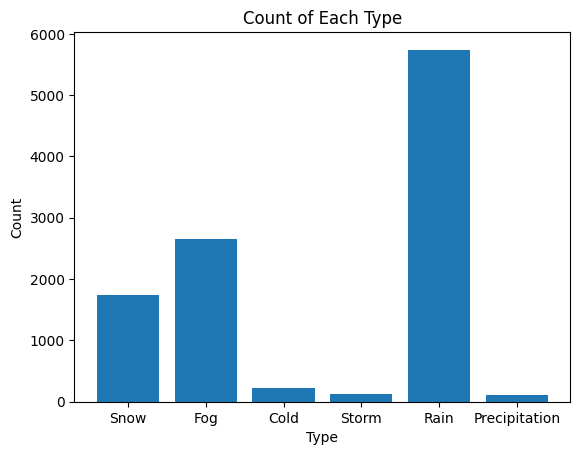

In [6]:
# A set of all the types in the data set.
Type_Set = set(data['Type'])

# Total count, key value pair
type_counts = Counter(data['Type'])

# X - All the keys or Types,    Y - Their Count
plt.bar(type_counts.keys(), type_counts.values())

# Simple LAbels and title
plt.xlabel('Type')
plt.ylabel('Count')
plt.title('Count of Each Type')

plt.show()

## Explaination
- A bar chart showing the count of different types of weather events.
- Helps identify the most common type of event in the dataset.
  <br>
  <br>
  <br>
  <br>
  <br>

## 2. Severity - Bar Graph

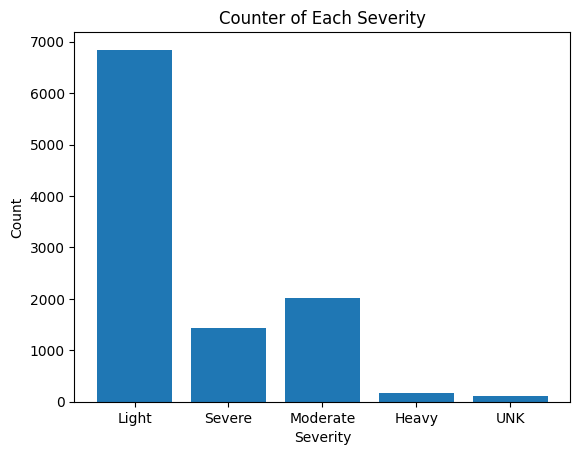

In [7]:

# Counting Severity
severity_count = Counter(data['Severity'])

# X - All the keys or Severities,    Y - Their Count
plt.bar(severity_count.keys(), severity_count.values())

# Simple LAbels and title
plt.xlabel('Severity')
plt.ylabel('Count')
plt.title('Counter of Each Severity')

plt.show()

## Explaination
- A histogram showing the frequency of different severity levels.
- Displays the distribution of severity levels to understand the intensity of events.
  <br>
  <br>
  <br>
  <br>
  <br>

## 3. [ Start & End ] Years - Line Chart

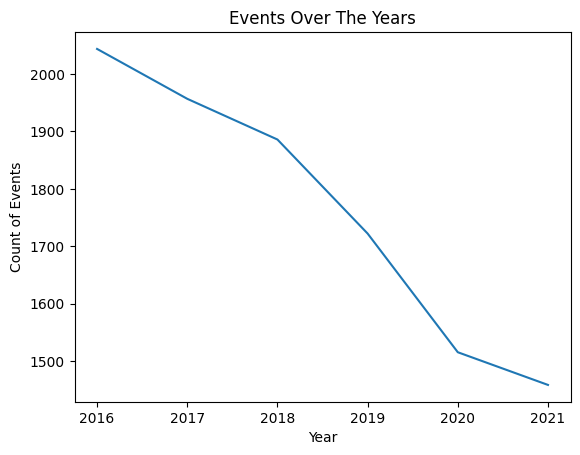

In [8]:

# From starttime, picking the Years Only
years = data['StartTime(UTC)'].dt.year

# COunt all the years mentioned in the data set
year_counts = years.value_counts()

# Specifing the Graph type
year_counts.plot(kind='line')

# Simple LAbels and title
plt.xlabel('Year')
plt.ylabel('Count of Events')
plt.title('Events Over The Years')

plt.show()

## Explaination
- A time series line chart of event occurrences over time.
- Shows count for the events in each year.
   <br>
  <br>
  <br>
  <br>
  <br>

## 4. Precipitation - Histogram

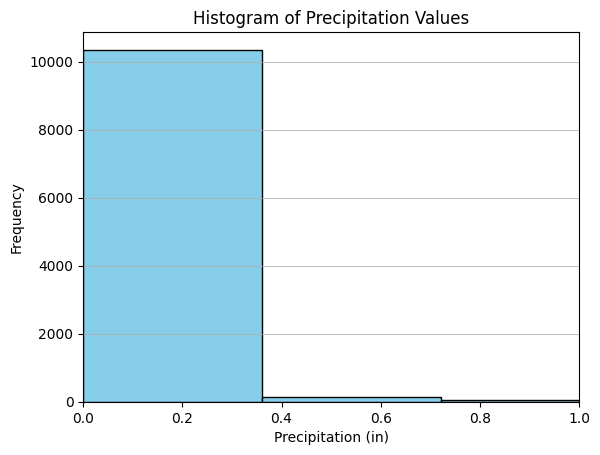

In [9]:
# First define the precipitation variable
precipitation = data['Precipitation(in)']

# Then create the histogram
plt.hist(precipitation, bins=20, color='skyblue', edgecolor='black')

# Rest of the plotting code
plt.xlim(0, 1)
plt.xlabel('Precipitation (in)')
plt.ylabel('Frequency')
plt.title('Histogram of Precipitation Values')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Explaination:
- Showing the distribution / probability of precipitation levels.
- By dividing into bins for each precipitation.
  <br>
  <br>
  <br>
  <br>
  <br>

## 5. TimeZone - Bar Graph

Text(0.5, 1.0, 'Distribution of Weather Events Across US - Time Zones')

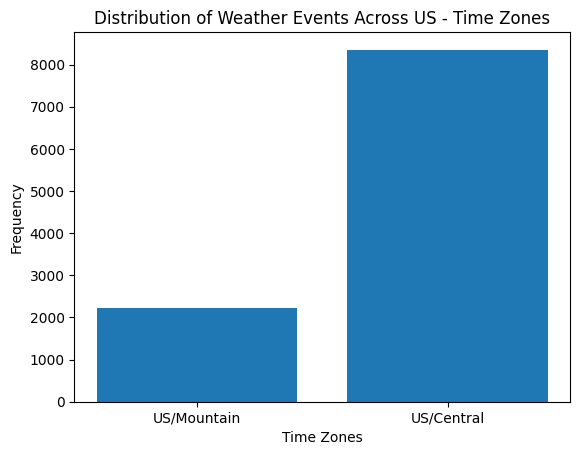

In [10]:

# Collecting us_time zones and counting them
US = data['TimeZone']
total_count = Counter(US)

# Separating the keys and values
timezones = list(total_count.keys())
counts = list(total_count.values())

# Giving x and Y for the Bar graph
plt.bar(timezones, counts)

# Labeling
plt.xlabel("Time Zones")
plt.ylabel("Frequency")
plt.title("Distribution of Weather Events Across US - Time Zones")


## Explaination
- A bar chart showing the count of events per time zone.
- Highlights where most weather events are recorded.
    <br>
    <br>
    <br>
    <br>
    <br>

## 6. Airport Code - Pie Chart

Text(0.5, 1.0, 'Distribution of Airports Across US')

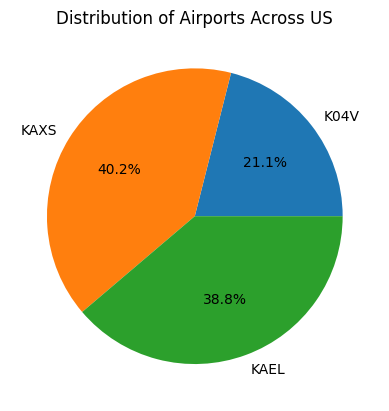

In [11]:

# Taking out Airport Codes and counting
AC = data['AirportCode']  
total_count = Counter(AC)

# separating airport codes and their counts
airportcode = list(total_count.keys())
counts = list(total_count.values())

# Pie chart with count value and it's labels
plt.pie(counts, labels=airportcode, autopct='%1.1f%%')

# Title
plt.title("Distribution of Airports Across US")


## Explaination:
- Shows Airport proportions code.
- Displays the composition among the Airports.
    <br>
    <br>
    <br>
    <br>
    <br>

## 7. Cities - Donut Chart

Text(0.5, 1.0, 'City Frequency Distribution (Donut Chart)')

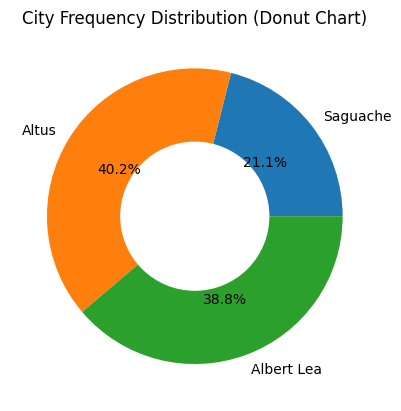

In [12]:
# Taking cities and counting
cities = data['City']
total_cities = Counter(cities)

# Extracting city names and counts
city_names = list(total_cities.keys())
counts = list(total_cities.values())

# A pie chart 
plt.pie(counts, labels=city_names, autopct='%1.1f%%')

# Adding a white circle in the center to make it a donut chart
centre_circle = plt.Circle((0, 0), 0.5, color='white')
plt.gca().add_artist(centre_circle)

# Title
plt.title("City Frequency Distribution (Donut Chart)")


## Explaination:
- Shows the frequency of cities in the data set.
- Shows each proportion of cities and their part in the data set similar to Pie Chart.
    <br>
    <br>
    <br>
    <br>
    <br>

## 8. County - Scatter Plot

Text(0.5, 1.0, 'County Frequency Distribution')

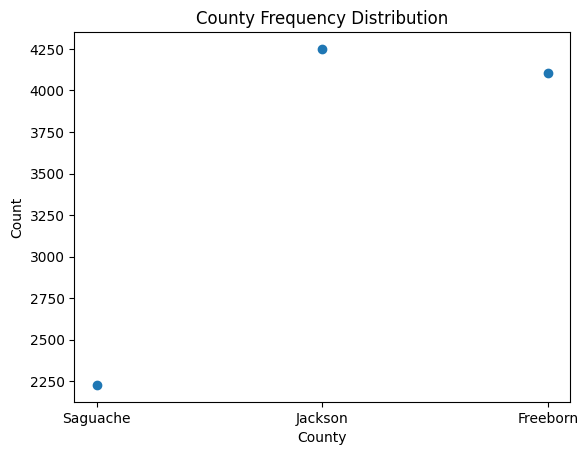

In [13]:
# Separate and count the number of Counties
County = data['County']
total_counties = Counter(County)

# Extract Counties names and counts
counties_names = list(total_counties.keys())
counts = list(total_counties.values())

# X-coordinates for Counties ( Jackson = 0, Freeborn = 1) etc... on the x axis
x_positions = range(len(total_counties))

# Create Scatter chart, with X - positions on X axis, Y - their total count
plt.scatter(x_positions, counts)

# labeling the x axis with their corresponding names, rather than 0's and 1's
plt.xticks(x_positions, counties_names)

# Labels and title
plt.xlabel("County")
plt.ylabel("Count")
plt.title("County Frequency Distribution")


## Explaination:
- The relationship of County and their total number.
- Shows trends and frequencey of each county in the data set.
    <br>
    <br>
    <br>
    <br>
    <br>

## 9. Zip Code - Scatter Plot

Text(0.5, 1.0, 'ZipCodes Frequency Distribution')

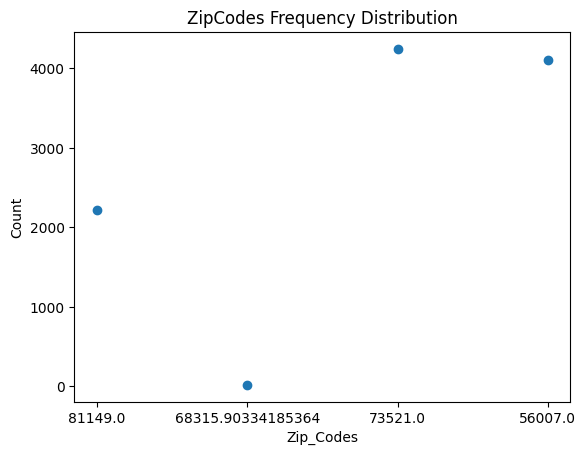

In [14]:
# Separate and count the number of Zip Code
ZipCode = data['ZipCode']
total_ZipCodes = Counter(ZipCode)

# Extract Zip Codes and counts
Zip_Codes = list(total_ZipCodes.keys())
counts = list(total_ZipCodes.values())

# X-coordinates for Zip Code ( 81149 = 0(index) ) etc... on the x axis
x_positions = range(len(total_ZipCodes))

# Create Scatter chart, with X - positions on X axis, Y - their total count
plt.scatter(x_positions, counts)

# labeling the x axis with their corresponding Codes, rather than 0's and 1's
plt.xticks(x_positions, Zip_Codes)

# Labels and title
plt.xlabel("Zip_Codes")
plt.ylabel("Count")
plt.title("ZipCodes Frequency Distribution")


## Explaination:
- The relationship of Zip Codes and their total number.
- Shows trends and frequencey of each Zip Code in the data set.
    <br>
    <br>
    <br>
    <br>
    <br>

## 10. State - Bar Graph

Text(0.5, 1.0, 'Distribution of State of Events Across US')

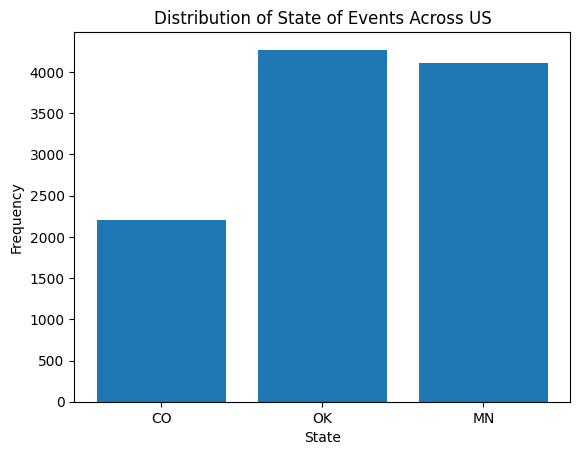

In [15]:

# Collecting State and counting them
State = data['State']
total_count = Counter(State)

# Separating the keys and values
States = list(total_count.keys())
counts = list(total_count.values())

# Giving x and Y for the Bar graph
plt.bar(States, counts)

# Labeling
plt.xlabel("State")
plt.ylabel("Frequency")
plt.title("Distribution of State of Events Across US")


## Explaination:
- Best for comparing discrete categories that are the State of events.
- Shows clear difference of event states. 
    <br>
    <br>
    <br>
    <br>
    <br>

## 11. Location Lat - Donut Chart

Text(0.5, 1.0, 'Location Latitude Distribution')

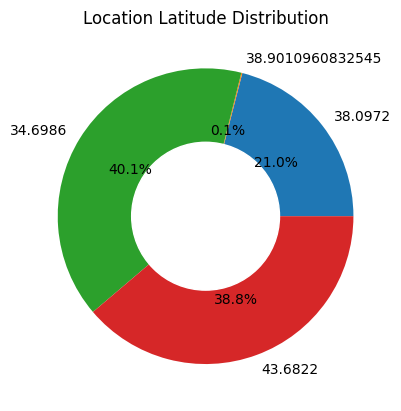

In [16]:
# Taking Location Lat and counting
LocationLat = data['LocationLat']
total_count = Counter(LocationLat)

# Extracting Location Lat and counts
total_lat = list(total_count.keys())
counts = list(total_count.values())

# A pie chart 
plt.pie(counts, labels=total_lat, autopct='%1.1f%%')

# Adding a white circle in the center to make it a donut chart
centre_circle = plt.Circle((0, 0), 0.5, color='white')
plt.gca().add_artist(centre_circle)

# Title
plt.title("Location Latitude Distribution")


## Explaination:
- Shows the propotion of each latitude in data set.
    <br>
    <br>
    <br>
    <br>
    <br>

## 12. Location Lng - Pie Chart

Text(0.5, 1.0, 'Distribution of location longitude')

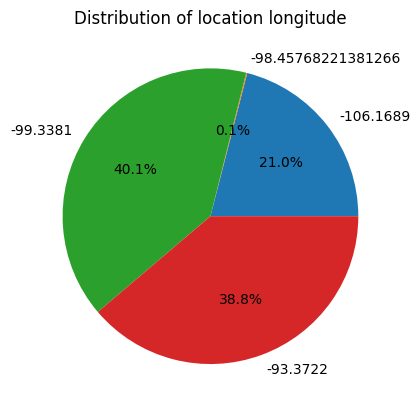

In [17]:

# Taking out Location lng and counting
LocationLng = data['LocationLng']  
total_count = Counter(LocationLng)

# separating Location lng and their counts
LocationLngs = list(total_count.keys())
counts = list(total_count.values())

# Pie chart with count value and it's Location lng
plt.pie(counts, labels=LocationLngs, autopct='%1.1f%%')

# Title
plt.title("Distribution of location longitude")


## Explaination:
- Shows the propotion of each Longitude in data set.
    <br>
    <br>
    <br>
    <br>
    <br>

# Task C: Advanced Feature Engineering

## 1.	Create New Features:

- Add a Duration feature that calculates the time difference (in hours) between StartTime(UTC) and EndTime(UTC).

In [18]:
# Turning 'StartTime(UTC)' into datetime and getting only the hour  
start = pd.to_datetime(data['StartTime(UTC)'], format='%m/%d/%y %H:%M').dt.hour  

# Doing the same for 'EndTime(UTC)', keeping only the hour part  
end = pd.to_datetime(data['EndTime(UTC)'], format='%m/%d/%y %H:%M').dt.hour  

# Finding the difference between start and end, making sure it's always positive  
difference = (end - start).abs()  

# Storing this difference in a new column for later use  
data['Duration[Hours]'] = difference  

# Printing the first few values to check if everything looks right  
print(data['Duration[Hours]'].head())  
print('\n\n\n\n\n')  


0    23
1     0
2    10
3     0
4     2
Name: Duration[Hours], dtype: int32








- Add a Season feature based on the month extracted from StartTime(UTC).

In [19]:
# Getting the month from 'StartTime(UTC)'  
month = pd.to_datetime(data['StartTime(UTC)'], format='%m/%d/%y %H:%M').dt.month  

# Setting a default season for all rows  
data['Season'] = 'Autumn'  

# Changing the season to 'Winter' for months 1 (Jan), 2 (Feb), and 12 (Dec)  
data.loc[data['month'].isin([1, 2, 12]), 'Season'] = 'Winter'  

# Setting 'Spring' for months between 3 (Mar) and 5 (May)  
data.loc[data['month'].between(3, 5), 'Season'] = 'Spring'  

# Setting 'Summer' for months between 6 (Jun) and 8 (Aug)  
data.loc[data['month'].between(6, 8), 'Season'] = 'Summer'  

# Printing the first 100 values to check if the seasons look correct  
print(data['Season'].head(100))  
print('\n\n\n\n\n')


0     Winter
1     Winter
2     Winter
3     Winter
4     Winter
       ...  
95    Spring
96    Spring
97    Spring
98    Spring
99    Spring
Name: Season, Length: 100, dtype: object








## 2.	Encoding Categorical Variables - Label Encoding:

- Convert the Severity column into numerical values using label encoding or one-hot encoding. Explain your choice of method.

In [20]:
# Getting all unique severity types from the 'Severity' column  
types_of_severities = data['Severity'].unique()  
print(types_of_severities)  # Printing them to see what values exist  

# Creating a mapping to assign numerical labels to severity levels  
severity_mapping = {'UNK': 0, 'Light': 1, 'Moderate': 2, 'Heavy': 3, 'Severe': 4}  

# Replacing severity labels with their corresponding numbers  
data['Severity[Label - Encoding]'] = data['Severity'].map(severity_mapping)  

# Printing the first 5 values to check if encoding is correct  
print(data['Severity[Label - Encoding]'].head(5))  
print('\n\n\n\n\n')  


['Light' 'Severe' 'Moderate' 'Heavy' 'UNK']
0    1
1    1
2    1
3    1
4    1
Name: Severity[Label - Encoding], dtype: int64








## Explaination:
- Used the Label Encoding as the data was ordinal.
- This assigns a unique numeric code to each severity level  {'UNK': 0, 'Light': 1, 'Moderate': 2, 'Heavy': 3, 'Severe': 4}.
  <br>
  <br>
  <br>
  <br>
  <br>

# Task D: Advanced Analysis

## 1.	Correlation Analysis:

In [21]:
# Calculating the correlation between 'Precipitation(in)' and 'Duration[Hours]'  
correlation = np.corrcoef(data['Precipitation(in)'], data['Duration[Hours]'])  

# Printing the correlation value to see the relationship between them  
print(f"Correlation Between Precipitation and Duration : \n{correlation}")  


Correlation Between Precipitation and Duration : 
[[1.         0.05880043]
 [0.05880043 1.        ]]


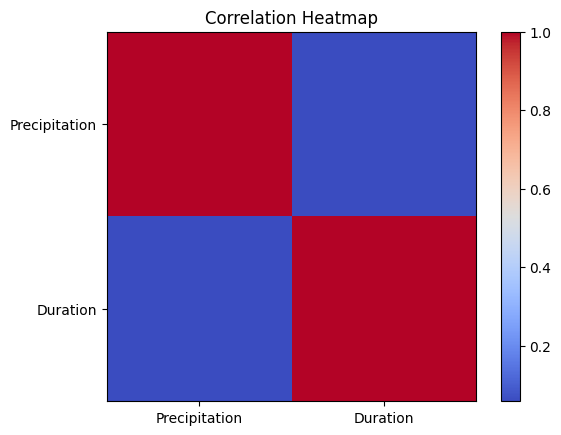

In [22]:
# Plotting the heatmap using Matplotlib  
plt.imshow(correlation, cmap='coolwarm')  # Using 'coolwarm' for better contrast  
plt.colorbar()  # Adding a color bar to show the correlation values  

# Adding labels for both axes  
plt.xticks([0, 1], ['Precipitation', 'Duration'])  
plt.yticks([0, 1], ['Precipitation', 'Duration'])  

# Showing the heatmap with a title  
plt.title("Correlation Heatmap")  
plt.show()  


## Explanation:
- It indicates the relationship between precipitation and duration.
- If the value is close to 1, it means they are highly positively correlated, If near 0, then is little or no correlation.
- Hence, in this case no correlation.
  <br>
  <br>
  <br>
  <br>
  <br>

## 2.	Outlier Detection:

Selected Q1 = 0.0
Selected Q3 = 0.6419000000000051



Lower Limit: -0.9628500000000078
Upper Limit: 1.604750000000013



Outliers in Precipitation: [1.61 1.68 1.7  1.75 1.82 1.83 1.85 1.94 2.02 2.02 2.03 2.11 2.24 2.56
 2.57 2.63 2.8  2.84 2.94 3.45 7.22]


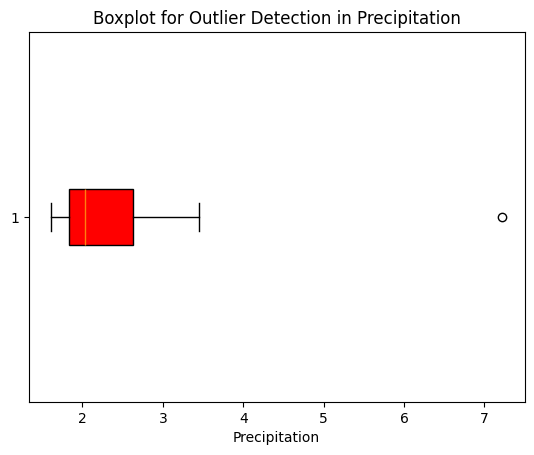

In [23]:
# Get precipitation values as a NumPy array  
precipitation = np.array(data['Precipitation(in)'])  

# Sort the values to make calculations easier  
precipitation = np.sort(precipitation)  # Returns a sorted copy  


# Find Q1 (25th percentile) and Q3 (75th percentile)  = 0.00
Q1 = np.percentile(precipitation, 25)  
Q3 = np.percentile(precipitation, 99)  


print(f"Selected Q1 = {Q1}")
print(f"Selected Q3 = {Q3}\n\n\n")

# Find the range (IQR) between Q1 and Q3  
IQR = Q3 - Q1  

# Set limits for what counts as an outlier  
lower_bound = Q1 - 1.5 * IQR  
upper_bound = Q3 + 1.5 * IQR  

print(f"Lower Limit: {lower_bound}")
print(f"Upper Limit: {upper_bound}\n\n\n")

# Find values that are too low or too high  
outliers = precipitation[(precipitation < lower_bound) | (precipitation > upper_bound)]  
print("Outliers in Precipitation:", outliers)  

# Show the outliers with a boxplot  
plt.boxplot(outliers, vert=False, patch_artist=True, boxprops=dict(facecolor="red"))  


plt.xlabel("Precipitation")
plt.title("Boxplot for Outlier Detection in Precipitation")  
plt.show()  


## Explanation of Outlier Handling:
### How to Handle These Outliers:
- 1. Remove Extreme Outliers: If the outliers seem like errors (e.g., unrealistic values), I would remove them to keep the data clean.
- 2. Cap the Outliers: If I think extreme values are possible but too extreme, I would replace them with the upper or lower boundary to prevent them from skewing results.
- 3. Use a Different Approach: Instead of removing, I could use a method like normalization to reduce their impact while keeping them in the dataset.
     <br>
  <br>
  <br>
  <br>
  <br>

## 3.	Geospatial Analysis:

[0 0 0 ... 0 0 1]
Index(['Snow', 'Fog', 'Cold', 'Storm', 'Rain'], dtype='object')


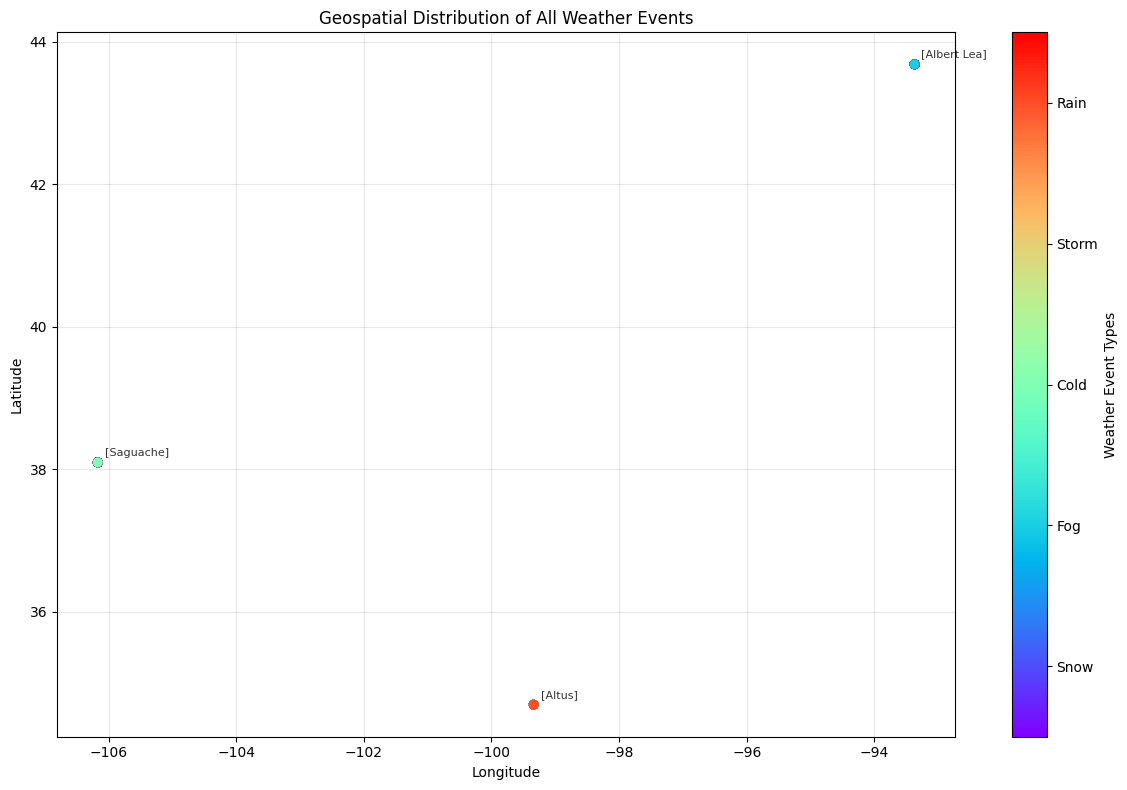

Events by location:
LocationLat  LocationLng  City        Type 
34.6986      -99.3381     Altus       Rain     2257
                                      Fog      1528
                                      Snow      116
                                      Cold       56
                                      Storm      51
38.0972      -106.1689    Saguache    Rain     1282
                                      Snow      769
                                      Fog        68
                                      Storm      67
                                      Cold       25
43.6822      -93.3722     Albert Lea  Rain     2128
                                      Fog       944
                                      Snow      850
                                      Cold      142
                                      Storm       3
Name: count, dtype: int64








In [24]:
# Filter out only Precipitation events but keep the rest of the data
filtered_file = file[file['Type'] != 'Precipitation']

# Create factorized values for coloring
weather_codes, weather_categories = pd.factorize(filtered_file['Type'])
print(weather_codes)
print(weather_categories)

plt.figure(figsize=(12, 8))


# Create scatter plot
scatter = plt.scatter(filtered_file['LocationLng'], filtered_file['LocationLat'], c=weather_codes, cmap='rainbow')


# Create a for loop to add city names
# We'll use a set to track which locations we've already labeled to avoid duplicates
labeled_locations = set()


for i, row in filtered_file.iterrows():
    
    # Creating a location key using lat/long
    loc_key = (row['LocationLat'], row['LocationLng'])
    
    # Only add the city label if we haven't labeled this location yet
    if loc_key not in labeled_locations:
        plt.annotate(f"[{row['City']}]", 
                    (row['LocationLng'], row['LocationLat']),
                    xytext=(5, 5), 
                    textcoords='offset points',
                    fontsize=8, 
                    alpha=0.8)
        # Add this location to our set of labeled locations
        labeled_locations.add(loc_key)

# Add labels and title
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geospatial Distribution of All Weather Events")

# Create legend with colorbar
cbar = plt.colorbar(scatter, label="Weather Event Types", ticks=range(len(weather_categories)))
plt.clim(-0.5, len(weather_categories)-0.5)
cbar.ax.set_yticklabels(weather_categories)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

# Optional: Print a summary of events per location
location_counts = filtered_file.groupby(['LocationLat', 'LocationLng', 'City'])['Type'].value_counts()
print("Events by location:")
print(location_counts)
print('\n\n\n\n\n')

## Geographical Distribution of Weather Events  

**Some places have more events than others.**  
   - As one location has more number of 1 type of events then others

**Some regions barely have any events.**  
   - Like Alber Lea having only 3 Storms.

**Rain is the most frequent event** 
- Across all listed locations, with Altus and Albert Lea experiencing the highest counts (2257 and 2128, respectively).  

**Fog is the second most common event**
- Significantly impacting Altus (1528) and Albert Lea (944), while being less frequent in Saguache (68).  

**Storms and Cold events are the least frequent**
- With Albert Lea having only 3 storm events, whereas Saguache and Altus show relatively higher but still low occurrences.  
